# **Spaceship Titanic Survival Prediction**

the goal of this project is to predict whether a passenger was transported to an alternate dimension during the Spaceship Titanic's collision with the spacetime anomaly, using a set of personal records recovered from the ship's damaged computer system

**Data Source:**  
[Kaggle Spaceship Titanic Competition](https://www.kaggle.com/competitions/spaceship-titanic/overview)

### data cleaning and processing section

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# fll missing values using similar data points (K-Nearest neighbors)
from sklearn.impute import KNNImputer

In [5]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

"""
to create the column in test dataset so its has the same structure as the training dataset before concatenating
also the False value is just a placeholder value and will be replaced later with the model's prediction
"""
df_test['Transported'] = False
df = pd.concat([df_train, df_test], sort = False)
df.drop(['Name', 'PassengerId'], axis = 1, inplace = True)
df.head(5)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


In [6]:
df.shape[0]== df_train.shape[0] + df_test.shape[0]

True

In [7]:
# The cabin number where the passenger is staying takes the form deck/num/side, so i Split it into three separate features
df[['Deck','Num','Side']] = df['Cabin'].str.split('/', expand = True)
df = df.drop(columns = ['Cabin'])

df['Deck'] = df['Deck'].fillna('U')
df['Num'] = df['Num'].fillna(0)
df['Side'] = df['Side'].fillna('U')

In [8]:
#label encoding
df['Deck'] = df['Deck'].map({'F':0,'G':1,'E':2,'B':3,'C':4,'D':5,'A':6,'U':7,'T':8})
df['Side'] = df['Side'].map({'U':-1,'P':1, 'S':2})

In [9]:
imputeList = ['Age', 'VIP', 'Num', 'CryoSleep', 'Side', 'Deck', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
rest = list(set(df.columns) - set(imputeList))
dfRest = df[rest]

imputer = KNNImputer(n_neighbors = 5)
df_imputed = imputer.fit_transform(df[imputeList])
df_imputed = pd.DataFrame(df_imputed, columns = imputeList)
df = pd.concat([df_imputed.reset_index(drop = True), dfRest.reset_index(drop = True)], axis = 1)

In [10]:
df['HomePlanet'] = df['HomePlanet'].fillna('U')
df['Destination'] = df['Destination'].fillna('U')

# one hot encoding
CategoryCols = ['HomePlanet', 'Destination']
for col in CategoryCols:
    pd.get_dummies(df[col], prefix = col)
    df = pd.concat([df, pd.get_dummies(df[col], prefix = col)], axis = 1)

df = df.drop(columns = CategoryCols)

In [11]:
df.isna().sum()

,0
Age,0
VIP,0
Num,0
CryoSleep,0
Side,0
Deck,0
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0


In [12]:
# features engneering
billCols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['AmountSpent'] = df[billCols].sum(axis = 1)
df['stdAmountSpent'] = df[billCols].std(axis = 1)
df['meanAmountSpent'] = df[billCols].mean(axis = 1)

df['3_high_cols'] = df['CryoSleep'] + df['HomePlanet_Europa'] + df['Destination_55 Cancri e']
df['3_low_cols'] = df['meanAmountSpent'] + df['AmountSpent'] + df['HomePlanet_Earth']

In [13]:
df.corr()['Transported'].sort_values(ascending = False)

,Transported
Transported,1.000000
CryoSleep,0.324518
3_high_cols,0.284237
HomePlanet_Europa,0.131977
Destination_55 Cancri e,0.083625
Deck,0.062790
Side,0.059872
FoodCourt,0.034766
HomePlanet_U,0.006403
HomePlanet_Mars,0.005643


In [14]:
n_train = df_train.shape[0]
df_train = df.iloc[:n_train]
df_test = df.iloc[n_train:]

df_test = df_test.drop(columns = ['Transported'])
df_train.shape, df_test.shape

((8693, 25), (4277, 24))

### machine learning section

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


In [30]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [34]:
x = df_train.drop(columns = ['Transported'])
y = df_train['Transported']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

model = XGBClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)


0.7947096032202415

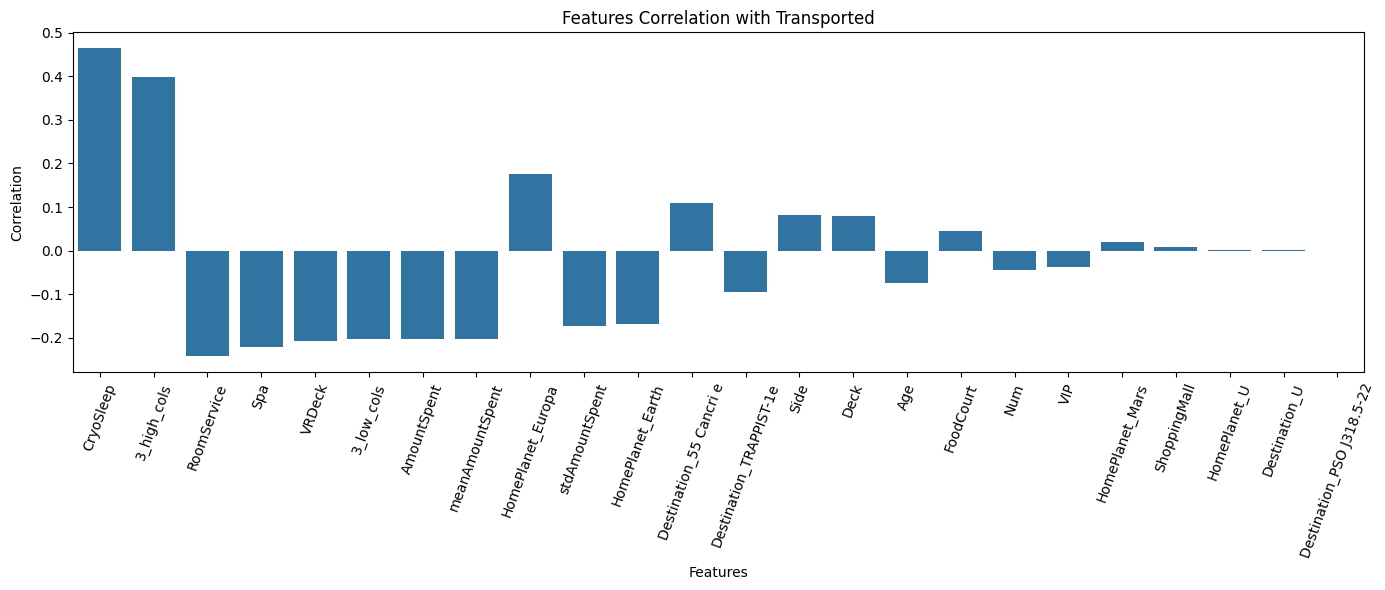

In [40]:
corr = (
    df_train
    .corr(numeric_only=True)['Transported']
    .drop('Transported')
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=corr.index,
    y=corr.values
)

plt.title('Features Correlation with Transported')
plt.xlabel('Features')
plt.ylabel('Correlation')

plt.xticks(rotation=70)

plt.tight_layout()
plt.show()